In [9]:
DATA_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)
REPORTS_DIR.mkdir(exist_ok=True)
print(ROOT_DIR)
print(TRAIN_FILE.exists())
print(TEST_FILE.exists())

/content
True
True


In [6]:
from pathlib import Path
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler


warnings.filterwarnings("ignore")




ROOT_DIR = Path.cwd()

DATA_DIR = ROOT_DIR / "data"
MODELS_DIR = ROOT_DIR / "models"
REPORTS_DIR = ROOT_DIR / "reports"

TRAIN_FILE = DATA_DIR / "UNSW_NB15_training-set.csv"
TEST_FILE = DATA_DIR / "UNSW_NB15_testing-set.csv"





def load_data() -> tuple[pd.DataFrame, pd.DataFrame]:
    """Carga train y test del dataset UNSW-NB15."""
    if not TRAIN_FILE.exists():
        raise FileNotFoundError(f"No se encontró el archivo: {TRAIN_FILE}")

    if not TEST_FILE.exists():
        raise FileNotFoundError(f"No se encontró el archivo: {TEST_FILE}")

    train_df = pd.read_csv(TRAIN_FILE)
    test_df = pd.read_csv(TEST_FILE)

    return train_df, test_df


def clean_target(df: pd.DataFrame) -> pd.DataFrame:
    """Limpia valores de attack_cat."""
    df = df.copy()

    if "attack_cat" not in df.columns:
        raise ValueError("El dataset no contiene la columna objetivo 'attack_cat'.")

    df["attack_cat"] = df["attack_cat"].astype(str).str.strip()

    # Algunas versiones usan Backdoors y otras Backdoor.
    df["attack_cat"] = df["attack_cat"].replace({
        "Backdoors": "Backdoor",
        "nan": np.nan,
        "": np.nan,
    })

    df = df.dropna(subset=["attack_cat"])

    return df


def split_features_target(train_df: pd.DataFrame, test_df: pd.DataFrame):
    """Separa X/y y elimina columnas que no deben usarse como features."""
    drop_cols = ["id", "label", "attack_cat"]

    y_train = train_df["attack_cat"]
    y_test = test_df["attack_cat"]

    X_train = train_df.drop(columns=drop_cols, errors="ignore")
    X_test = test_df.drop(columns=drop_cols, errors="ignore")

    return X_train, X_test, y_train, y_test


def build_preprocessor(X_train: pd.DataFrame) -> ColumnTransformer:
    """Crea preprocesador para variables categóricas y numéricas."""
    categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
    numeric_cols = X_train.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()

    categorical_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    numeric_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", categorical_pipeline, categorical_cols),
            ("num", numeric_pipeline, numeric_cols),
        ],
        remainder="drop",
    )

    print("Columnas categóricas:", categorical_cols)
    print("Cantidad columnas numéricas:", len(numeric_cols))

    return preprocessor

def get_models() -> dict:
    return {
        "logistic_regression": LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            n_jobs=-1,
        ),
        "random_forest": RandomForestClassifier(
            n_estimators=250,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1,
        ),
    }



def evaluate_model(name, pipeline, X_test, y_test_encoded, label_encoder):
    """Evalúa modelo y devuelve métricas principales."""
    y_pred = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test_encoded, y_pred)
    precision_macro = precision_score(y_test_encoded, y_pred, average="macro", zero_division=0)
    recall_macro = recall_score(y_test_encoded, y_pred, average="macro", zero_division=0)
    f1_macro = f1_score(y_test_encoded, y_pred, average="macro", zero_division=0)
    f1_weighted = f1_score(y_test_encoded, y_pred, average="weighted", zero_division=0)

    print("\n" + "=" * 80)
    print(f"Modelo: {name}")
    print("=" * 80)
    print(f"Accuracy:     {accuracy:.4f}")
    print(f"Precision M:  {precision_macro:.4f}")
    print(f"Recall M:     {recall_macro:.4f}")
    print(f"F1 Macro:     {f1_macro:.4f}")
    print(f"F1 Weighted:  {f1_weighted:.4f}")

    print("\nReporte por clase:")
    print(classification_report(
        y_test_encoded,
        y_pred,
        target_names=label_encoder.classes_,
        zero_division=0,
    ))

    return {
        "model": name,
        "accuracy": accuracy,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
    }, y_pred


def save_confusion_matrix(y_test_encoded, y_pred, label_encoder):
    """Guarda matriz de confusión del mejor modelo."""
    cm = confusion_matrix(y_test_encoded, y_pred)

    fig, ax = plt.subplots(figsize=(12, 10))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_encoder.classes_,
    )
    disp.plot(ax=ax, xticks_rotation=90, cmap=None, values_format="d")
    ax.set_title("Matriz de confusión - UNSW-NB15 multiclase")
    plt.tight_layout()

    output_path = REPORTS_DIR / "confusion_matrix.png"
    plt.savefig(output_path, dpi=150)


    # Mostrar visualmente la matriz en Colab / Jupyter
    plt.show()

    plt.close()

    print(f"Matriz de confusión guardada en: {output_path}")


def main():
    print("Cargando datos...")
    train_df, test_df = load_data()

    print("Shape train:", train_df.shape)
    print("Shape test:", test_df.shape)

    train_df = clean_target(train_df)
    test_df = clean_target(test_df)

    print("\nDistribución de clases en train:")
    print(train_df["attack_cat"].value_counts())

    print("\nDistribución de clases en test:")
    print(test_df["attack_cat"].value_counts())

    X_train, X_test, y_train, y_test = split_features_target(train_df, test_df)

    label_encoder = LabelEncoder()
    y_train_encoded = label_encoder.fit_transform(y_train)
    y_test_encoded = label_encoder.transform(y_test)

    print("\nClases:")
    print(list(label_encoder.classes_))

    preprocessor = build_preprocessor(X_train)
    models = get_models()

    results = []
    trained_pipelines = {}
    predictions = {}

    for name, model in models.items():
        pipeline = Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ])

        print(f"\nEntrenando modelo: {name}")
        pipeline.fit(X_train, y_train_encoded)

        metrics, y_pred = evaluate_model(
            name,
            pipeline,
            X_test,
            y_test_encoded,
            label_encoder,
        )

        results.append(metrics)
        trained_pipelines[name] = pipeline
        predictions[name] = y_pred

    results_df = pd.DataFrame(results).sort_values(by="f1_macro", ascending=False)
    results_path = REPORTS_DIR / "model_results.csv"
    results_df.to_csv(results_path, index=False)

    print("\nResultados comparativos:")
    print(results_df)

    best_model_name = results_df.iloc[0]["model"]
    best_pipeline = trained_pipelines[best_model_name]
    best_y_pred = predictions[best_model_name]

    print(f"\nMejor modelo según F1 Macro: {best_model_name}")

    joblib.dump(best_pipeline, MODELS_DIR / "best_model.joblib")
    joblib.dump(label_encoder, MODELS_DIR / "label_encoder.joblib")

    report_text = classification_report(
        y_test_encoded,
        best_y_pred,
        target_names=label_encoder.classes_,
        zero_division=0,
    )

    with open(REPORTS_DIR / "classification_report.txt", "w", encoding="utf-8") as f:
        f.write(f"Mejor modelo: {best_model_name}\n\n")
        f.write(report_text)

    save_confusion_matrix(y_test_encoded, best_y_pred, label_encoder)

    print("\nModelo guardado en models/best_model.joblib")
    print("Label encoder guardado en models/label_encoder.joblib")
    print("Reporte guardado en reports/classification_report.txt")



Cargando datos...
Shape train: (82332, 45)
Shape test: (175341, 45)

Distribución de clases en train:
attack_cat
Normal            37000
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
Reconnaissance     3496
Analysis            677
Backdoor            583
Shellcode           378
Worms                44
Name: count, dtype: int64

Distribución de clases en test:
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64

Clases:
['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Normal', 'Reconnaissance', 'Shellcode', 'Worms']
Columnas categóricas: ['proto', 'service', 'state']
Cantidad columnas numéricas: 39

Entrenando modelo: logistic_regression

Modelo: logistic_regression
Accuracy:     0.7089
Precision M:

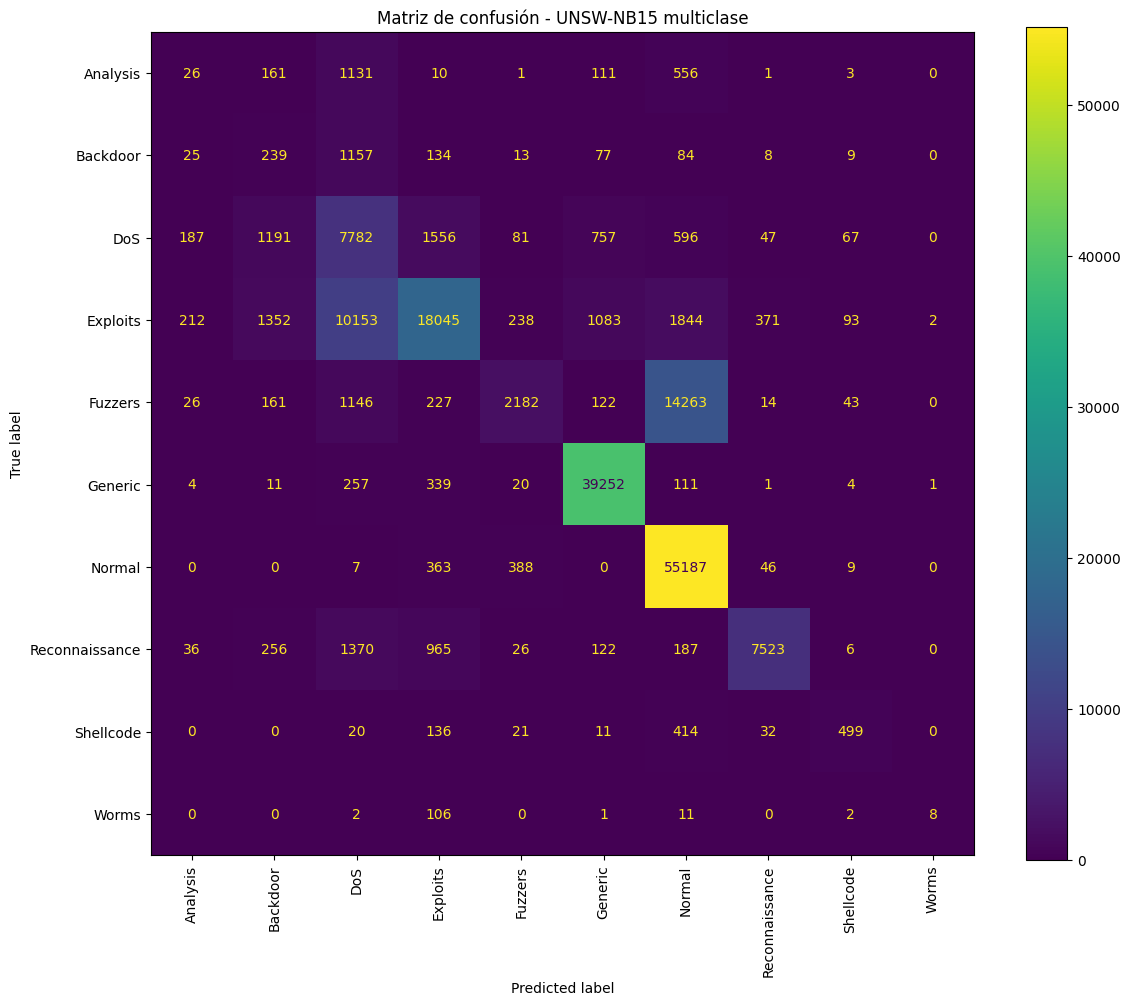

Matriz de confusión guardada en: /content/reports/confusion_matrix.png

Modelo guardado en models/best_model.joblib
Label encoder guardado en models/label_encoder.joblib
Reporte guardado en reports/classification_report.txt


In [7]:

if __name__ == "__main__":
    main()